# EDA — Adult Census Income 1994

## Propósito

Explorar el dataset limpio y validado para identificar patrones técnicamente relevantes que conduzcan a decisiones de modelado, ingeniería de variables o negocio.

## Punto de partida

Este EDA utiliza el archivo:

`data/processed/adult_clean.csv`

El dataset fue previamente sometido a:

- diagnóstico de Data Quality;
- limpieza reproducible;
- Data Quality Gates;
- validación posterior a la limpieza.

Resultado esperado de entrada:

- 48,790 registros;
- 15 variables;
- sin valores faltantes;
- sin duplicados;
- target `income` normalizado a `<=50K` y `>50K`.

## Pregunta guía

***¿Qué patrones ayudan a comprender y predecir quién supera los US$50K y qué decisiones para el modelo se desprenden de ellos?***

In [1]:
#importación de librerias 

from pathlib import Path
import pandas as pd

#creación de data set 

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "adult_clean.csv"

df = pd.read_csv(DATA_PATH)

df.shape

(48790, 15)

In [2]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48790 entries, 0 to 48789
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48790 non-null  int64
 1   workclass       48790 non-null  str  
 2   fnlwgt          48790 non-null  int64
 3   education       48790 non-null  str  
 4   education-num   48790 non-null  int64
 5   marital-status  48790 non-null  str  
 6   occupation      48790 non-null  str  
 7   relationship    48790 non-null  str  
 8   race            48790 non-null  str  
 9   sex             48790 non-null  str  
 10  capital-gain    48790 non-null  int64
 11  capital-loss    48790 non-null  int64
 12  hours-per-week  48790 non-null  int64
 13  native-country  48790 non-null  str  
 14  income          48790 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


### Validación del punto de partida

El dataset cargado contiene **48,790 registros y 15 variables**, coincidiendo con la salida validada del pipeline de Data Quality.

Esto confirma que el EDA parte del dataset limpio (`adult_clean.csv`) y no del dataset raw.

## 2. Análisis de la variable objetivo: `income`

### Objetivo

Comprender la distribución de la variable objetivo que el modelo deberá predecir: si una persona pertenece a la categoría de ingreso `<=50K` o `>50K`.

### Preguntas de análisis

- ¿Cuántos registros pertenecen a cada clase?
- ¿Qué proporción representa cada categoría?
- ¿Existe un desbalance relevante entre las clases?
- ¿Qué implicaciones podría tener esta distribución para el entrenamiento y la evaluación del modelo?

### ¿Por qué importa?

Antes de analizar las variables predictoras es necesario comprender la variable que queremos predecir.

Si una clase aparece con mucha mayor frecuencia que la otra, un modelo podría obtener una exactitud aparentemente alta favoreciendo la clase mayoritaria, sin necesariamente identificar adecuadamente la clase `>50K`.

Este análisis servirá como evidencia para decidir posteriormente la estrategia de partición de los datos y las métricas apropiadas para evaluar los modelos.

In [4]:
# Primera comprobación - Frecuecias Absolutas: 

conteo_income = df["income"].value_counts()

conteo_income

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [5]:
# Segunda comprobación - Frecuencia porcentual

porcentaje_income = df["income"].value_counts(normalize=True).mul(100).round(2)

porcentaje_income

income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64

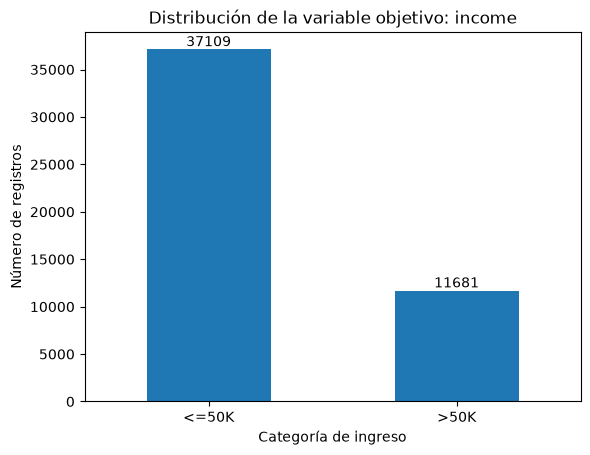

In [6]:
# Grafico para analizar desbalance de clases:

import matplotlib.pyplot as plt

ax = conteo_income.plot(kind="bar")

plt.title("Distribución de la variable objetivo: income")
plt.xlabel("Categoría de ingreso")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Hallazgo

La variable objetivo presenta una distribución desigual:

- `<=50K`: **37,109 registros (76.06%)**
- `>50K`: **11,681 registros (23.94%)**

La clase `<=50K` representa aproximadamente tres cuartas partes del dataset.

### Interpretación

El problema presenta un **desbalance moderado de clases**. Esto implica que la exactitud (`accuracy`) por sí sola puede ofrecer una visión incompleta del desempeño.

Un clasificador que asignara todos los registros a la clase mayoritaria `<=50K` alcanzaría aproximadamente **76.06% de accuracy**, aun cuando no identificara ningún caso `>50K`.

### Decisión para el modelado

Como consecuencia de este hallazgo:

1. La separación posterior entre entrenamiento y prueba deberá preservar la proporción de las clases mediante **estratificación**.
2. La evaluación no deberá depender únicamente de `accuracy`.
3. Se deberán considerar métricas como **precision, recall, F1-score y ROC-AUC**, prestando especial atención al desempeño sobre la clase `>50K`.
4. No se aplicarán todavía técnicas de balanceo. Su necesidad deberá evaluarse posteriormente a partir del desempeño de los modelos.

**Decisión:** conservar la distribución observada como punto de partida y considerar explícitamente el desbalance durante el entrenamiento y la evaluación.

## 3. Análisis de las variables numéricas

### Objetivo

Comprender la distribución y el comportamiento de las variables numéricas del dataset, identificando características que puedan influir en decisiones posteriores de modelado o ingeniería de variables.

### Preguntas de análisis

- ¿Cómo se distribuyen las variables numéricas?
- ¿Presentan asimetrías importantes?
- ¿Existen concentraciones, ceros o valores extremos que requieran atención?
- ¿Los valores extremos parecen errores o casos plausibles?
- ¿Alguna variable requiere un tratamiento diferente antes del modelado?
- ¿Qué análisis adicionales debemos realizar posteriormente respecto a `income`?

### ¿Por qué importa?

Los modelos de Machine Learning pueden responder de manera diferente ante variables con escalas muy distintas, distribuciones altamente asimétricas, concentraciones de ceros o valores extremos.

El propósito de este bloque no es transformar todavía las variables, sino identificar qué características requieren una investigación más profunda antes de tomar decisiones de Feature Engineering.

In [7]:
# Identificación de variables

variables_numericas = df.select_dtypes(include="number").columns.tolist()

variables_numericas

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [8]:
# Radiografía estadística: 

df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.652798,13.708493,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189668.999365,105617.231232,12285.0,117555.0,178138.5,237606.25,1490400.0
education-num,48790.0,10.078807,2.570046,1.0,9.0,10.0,12.00,16.0
capital-gain,48790.0,1080.217688,7455.905921,0.0,0.0,0.0,0.00,99999.0
capital-loss,48790.0,87.595573,403.209129,0.0,0.0,0.0,0.00,4356.0
hours-per-week,48790.0,40.425886,12.392729,1.0,40.0,40.0,45.00,99.0


In [9]:
# Asimetría de variables: 

asimetria = df[variables_numericas].skew().sort_values(ascending=False)

asimetria

capital-gain      11.888265
capital-loss       4.567037
fnlwgt             1.439698
age                0.556582
hours-per-week     0.239652
education-num     -0.314229
dtype: float64

Los estadísticos descriptivos y la asimetría fueron examinados previamente
durante Data Quality. En este EDA se utilizan únicamente como referencia
para seleccionar los análisis que pueden conducir a decisiones de modelado.

Por esta razón, no se repite el diagnóstico de calidad ni se generan
visualizaciones descriptivas para cada variable.

### 3.1 Edad e ingreso (`age` → `income`)

#### Objetivo

Analizar cómo cambia la proporción de personas con ingresos `>50K` según la edad e identificar si la relación parece lineal o presenta etapas o patrones diferenciados.

#### Preguntas de análisis

- ¿La proporción de `>50K` aumenta conforme aumenta la edad?
- ¿La relación parece lineal o presenta diferentes etapas?
- ¿Existen edades o rangos con muy pocas observaciones que puedan generar patrones poco robustos?
- ¿La evidencia sugiere mantener `age` como variable continua o considerar posteriormente alguna transformación?

#### ¿Por qué importa?

La edad puede estar relacionada con experiencia, trayectoria laboral y etapa profesional. Sin embargo, asumir una relación lineal podría simplificar excesivamente el patrón real.

Comprender su comportamiento respecto a `income` permitirá evaluar posteriormente si conviene utilizar la edad directamente, transformarla o permitir que el modelo capture relaciones no lineales.

In [10]:
# Proporción de edad e ingreso

age_income = (
    df.groupby("age")["income"]
      .apply(lambda x: (x == ">50K").mean() * 100)
      .reset_index(name="porcentaje_mayor_50K")
)

age_income.head(10)

,age,porcentaje_mayor_50K
0,17,0.000000
1,18,0.000000
2,19,0.287081
3,20,0.090009
4,21,0.549451
5,22,1.445578
6,23,1.660377
7,24,3.651452
8,25,6.386555
9,26,7.372073


In [11]:
conteo_edad = (
    df.groupby("age")
      .size()
      .reset_index(name="n")
)

age_income = age_income.merge(conteo_edad, on="age")

age_income

,age,porcentaje_mayor_50K,n
0,17,0.000000,594
1,18,0.000000,861
2,19,0.287081,1045
3,20,0.090009,1111
4,21,0.549451,1092
...,...,...,...
69,86,0.000000,1
70,87,0.000000,3
71,88,16.666667,6
72,89,0.000000,2


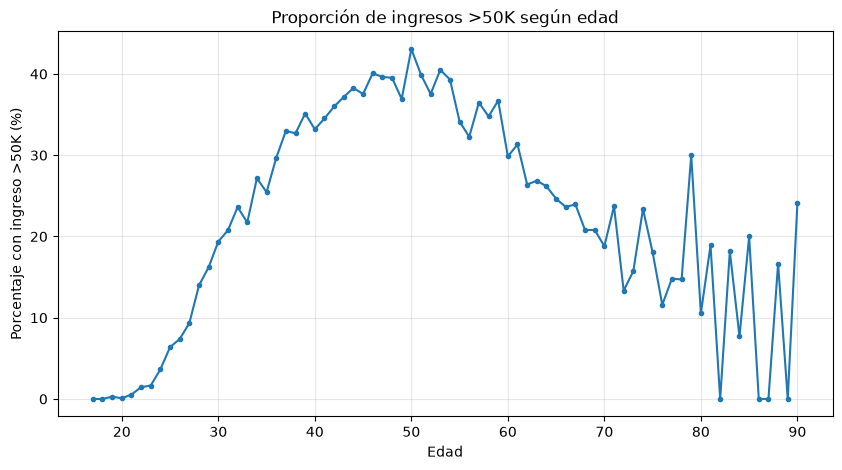

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    age_income["age"],
    age_income["porcentaje_mayor_50K"],
    marker="o",
    markersize=3
)

plt.title("Proporción de ingresos >50K según edad")
plt.xlabel("Edad")
plt.ylabel("Porcentaje con ingreso >50K (%)")
plt.grid(alpha=0.3)

plt.show()

In [13]:
age_income.tail(20)

,age,porcentaje_mayor_50K,n
54,71,23.728814,118
55,72,13.333333,120
56,73,15.740741,108
57,74,23.376623,77
58,75,18.055556,72
59,76,11.594203,69
60,77,14.814815,54
61,78,14.705882,34
62,79,30.000000,30
63,80,10.526316,38


In [14]:
age_income.loc[age_income["n"] < 30]

,age,porcentaje_mayor_50K,n
65,82,0.000000,15
66,83,18.181818,11
67,84,7.692308,13
68,85,20.000000,5
69,86,0.000000,1
70,87,0.000000,3
71,88,16.666667,6
72,89,0.000000,2


#### Hallazgo y decisión

La relación entre `age` e `income` es **no lineal**: la proporción de `>50K` aumenta hasta edades intermedias y posteriormente disminuye.

La variabilidad observada en edades avanzadas coincide con grupos de muy pocos registros, por lo que no se interpreta como un patrón estable.

**Decisión:** mantener `age` como predictor y permitir que el modelado capture su comportamiento no lineal. No crear rangos de edad de forma arbitraria en esta etapa.

### 3.2 Educación e ingreso

**Pregunta:** ¿`education` y `education-num` representan información redundante y cómo se relacionan con `income`?

**Propósito:** determinar si ambas variables aportan información diferente antes de Feature Engineering.

In [15]:
# Relación entre variables educación:

educacion_equivalencia = (
    df.groupby(["education", "education-num"])
      .size()
      .reset_index(name="n")
      .sort_values("education-num")
)

educacion_equivalencia

,education,education-num,n
13,Preschool,1,81
3,1st-4th,2,245
4,5th-6th,3,507
5,7th-8th,4,954
6,9th,5,756
0,10th,6,1389
1,11th,7,1812
2,12th,8,655
11,HS-grad,9,15770
15,Some-college,10,10863


In [16]:
df.groupby("education")["education-num"].nunique().sort_values(ascending=False)

education
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1
Name: education-num, dtype: int64

In [17]:
#Proporción de >50K por nivel educativo 

educacion_income = (
    df.groupby(["education-num", "education"])["income"]
      .apply(lambda x: (x == ">50K").mean() * 100)
      .reset_index(name="porcentaje_mayor_50K")
      .sort_values("education-num")
)

educacion_income

,education-num,education,porcentaje_mayor_50K
0,1,Preschool,1.234568
1,2,1st-4th,3.265306
2,3,5th-6th,5.325444
3,4,7th-8th,6.498952
4,5,9th,5.423280
5,6,10th,6.263499
6,7,11th,5.077263
7,8,12th,7.328244
8,9,HS-grad,15.859226
9,10,Some-college,18.972659


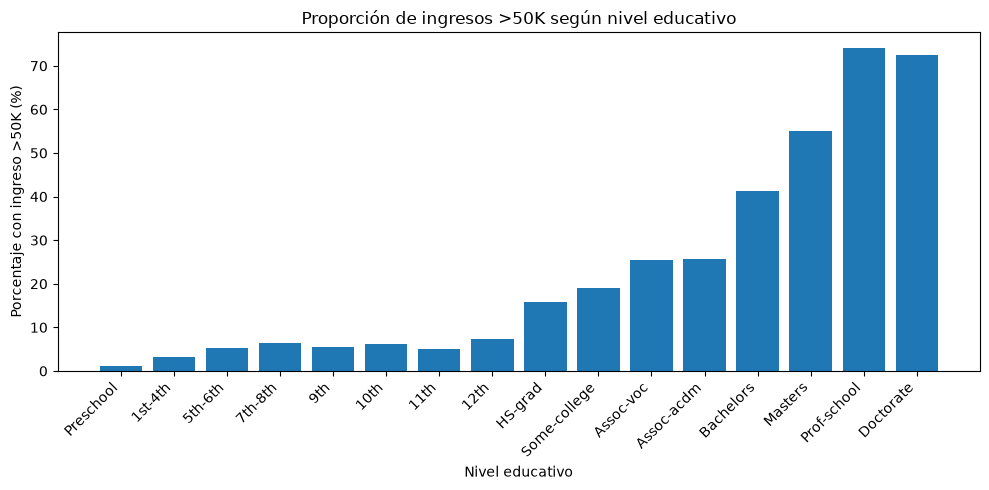

In [18]:
# Grafico de relación educación ingresos > 50K

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    educacion_income["education"],
    educacion_income["porcentaje_mayor_50K"]
)

plt.title("Proporción de ingresos >50K según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Porcentaje con ingreso >50K (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

#### Hallazgo y decisión

La educación muestra una **fuerte asociación con `income`**: la proporción de `>50K`
aumenta especialmente en los niveles educativos superiores.

Además, `education` y `education-num` representan el mismo nivel educativo mediante
una correspondencia uno a uno.

**Decisión:** conservar la educación como predictor relevante y evitar utilizar ambas
representaciones simultáneamente sin evaluar su redundancia. La representación final
se definirá en Feature Engineering según el modelo utilizado.

### 3.3 Horas trabajadas e ingreso

**Pregunta:** ¿Cómo cambia la proporción de `>50K` según las horas trabajadas por semana?

**Propósito:** identificar si existe una relación progresiva, umbrales o patrones no lineales que puedan influir en el modelado.

In [19]:
#1era Exploración: Horas exactas

horas_income = (
    df.groupby("hours-per-week")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
)

horas_income

,hours-per-week,n,porcentaje_mayor_50K
0,1,27,11.111111
1,2,53,22.641509
2,3,59,5.084746
3,4,84,7.142857
4,5,95,9.473684
...,...,...,...
91,95,2,50.000000
92,96,9,11.111111
93,97,2,50.000000
94,98,14,21.428571


In [20]:
df["hours-per-week"].value_counts().head(15)

hours-per-week
40    22773
50     4242
45     2715
60     2177
35     1934
20     1860
30     1699
55     1050
25      957
48      768
38      714
15      623
70      437
32      423
10      421
Name: count, dtype: int64

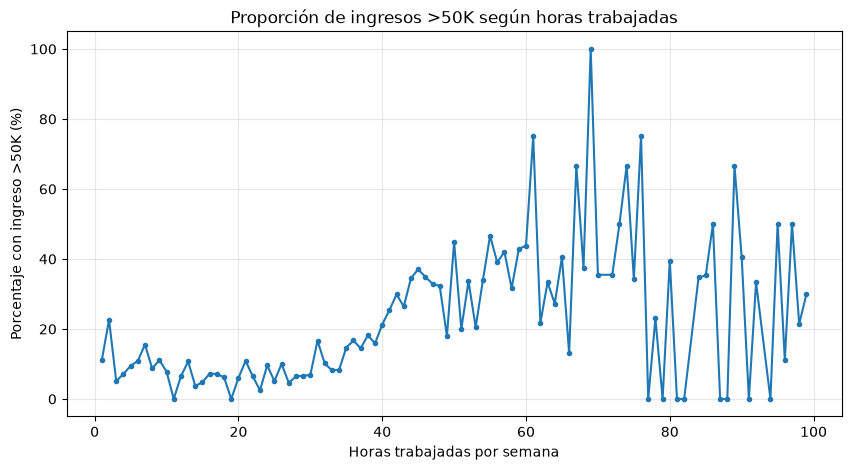

In [21]:
# Grafico relación horas trabajadas Ingresos >50k 

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    horas_income["hours-per-week"],
    horas_income["porcentaje_mayor_50K"],
    marker="o",
    markersize=3
)

plt.title("Proporción de ingresos >50K según horas trabajadas")
plt.xlabel("Horas trabajadas por semana")
plt.ylabel("Porcentaje con ingreso >50K (%)")
plt.grid(alpha=0.3)

plt.show()

In [22]:
# Agrupamiento por horas 

bins = [0, 20, 35, 40, 45, 60, 100]
labels = ["1-20", "21-35", "36-40", "41-45", "46-60", "61-99"]

df["hours_group"] = pd.cut(
    df["hours-per-week"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

horas_grupo = (
    df.groupby("hours_group", observed=True)["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
)

horas_grupo

,hours_group,n,porcentaje_mayor_50K
0,1-20,4446,6.770130
1,21-35,5874,9.584610
2,36-40,24127,21.042815
3,41-45,3649,35.324747
4,46-60,9018,42.714571
5,61-99,1676,35.739857


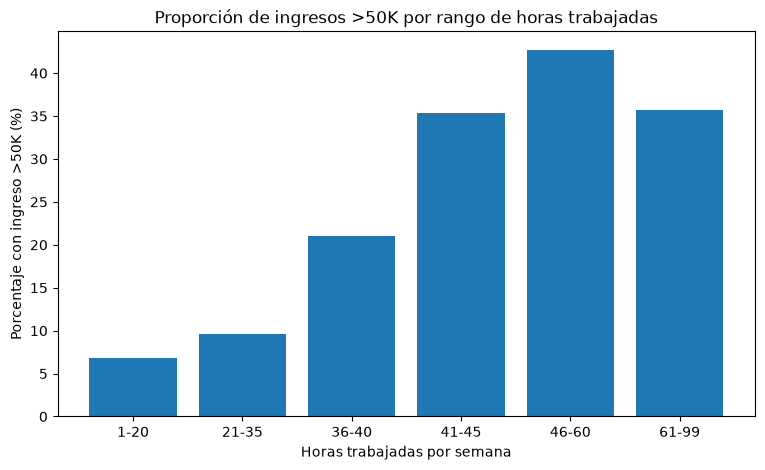

In [23]:
#Gráfico por rango de horas y relación ingresos >50K 

plt.figure(figsize=(9, 5))

plt.bar(
    horas_grupo["hours_group"],
    horas_grupo["porcentaje_mayor_50K"]
)

plt.title("Proporción de ingresos >50K por rango de horas trabajadas")
plt.xlabel("Horas trabajadas por semana")
plt.ylabel("Porcentaje con ingreso >50K (%)")

plt.show()

#### Hallazgo y decisión

La proporción de `>50K` aumenta con las horas trabajadas hasta el rango de **46–60 horas**, pero disminuye posteriormente. Además, las **40 horas concentran cerca del 47% de los registros**.

**Decisión:** mantener `hours-per-week` como predictor y considerar su comportamiento no lineal. Los rangos utilizados son exploratorios; cualquier transformación se evaluará posteriormente en Feature Engineering.

In [24]:
# Eliminamos la variable auxiliar creada únicamente para el análisis exploratorio
df.drop(columns=["hours_group"], inplace=True)

### 3.4 Ganancias y pérdidas de capital

**Contexto:** `capital-gain` y `capital-loss` no representan salario ni ingreso laboral.

Se refieren a ganancias o pérdidas de capital declaradas, asociadas a operaciones con activos o inversiones (por ejemplo, venta de acciones u otros bienes). Por ello, una persona puede registrar `capital-gain = 0` y aun tener un ingreso laboral elevado.

**Pregunta:** ¿la presencia de ganancias o pérdidas de capital aporta una señal relevante para distinguir `>50K`?

**Propósito:** determinar si estas variables deben tratarse por su valor original o si su alta concentración de ceros sugiere otra representación.

In [25]:
# ¿Cuántas personas tienen ganancias o pérdidas de capital? 

capital_resumen = pd.DataFrame({
    "Variable": ["capital-gain", "capital-loss"],
    "Con valor 0": [
        (df["capital-gain"] == 0).sum(),
        (df["capital-loss"] == 0).sum()
    ],
    "Con valor > 0": [
        (df["capital-gain"] > 0).sum(),
        (df["capital-loss"] > 0).sum()
    ]
})

capital_resumen["% con valor > 0"] = (
    capital_resumen["Con valor > 0"] / len(df) * 100
).round(2)

capital_resumen

,Variable,Con valor 0,Con valor > 0,% con valor > 0
0,capital-gain,44755,4035,8.27
1,capital-loss,46508,2282,4.68


In [26]:
#¿Qué porcentaje supera US$50K en cada grupo?

for variable in ["capital-gain", "capital-loss"]:
    resultado = (
        df.assign(presencia=df[variable] > 0)
          .groupby("presencia")["income"]
          .apply(lambda x: (x == ">50K").mean() * 100)
    )
    
    print(f"\n{variable}")
    print(resultado)


capital-gain
presencia
False    20.534019
True     61.734820
Name: income, dtype: float64

capital-loss
presencia
False    22.656317
True     50.131464
Name: income, dtype: float64


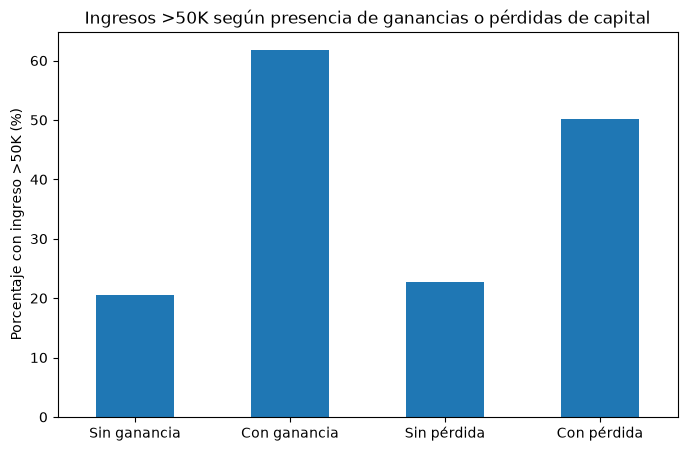

In [27]:
# Graficos para evaluar relaciones con el ingreso 

capital_comparacion = pd.DataFrame({
    "Grupo": [
        "Sin ganancia",
        "Con ganancia",
        "Sin pérdida",
        "Con pérdida"
    ],
    "Porcentaje >50K": [
        20.534019,
        61.734820,
        22.656317,
        50.131464
    ]
})

capital_comparacion.plot(
    x="Grupo",
    y="Porcentaje >50K",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Ingresos >50K según presencia de ganancias o pérdidas de capital")
plt.xlabel("")
plt.ylabel("Porcentaje con ingreso >50K (%)")
plt.xticks(rotation=0)
plt.show()

#### Hallazgo y decisión

Aunque `capital-gain` y `capital-loss` son distintos de cero solo en **8.27% y 4.68%** de los registros, su presencia muestra una fuerte asociación con `income`.

La proporción de `>50K` pasa de **20.5% a 61.7%** cuando existe ganancia de capital y de **22.7% a 50.1%** cuando existe pérdida de capital.

**Decisión:** conservar ambas variables y evaluar en Feature Engineering una representación adicional de presencia (`0/1`), sin interpretar esta asociación como causal.

### 3.5 Peso muestral (`fnlwgt`)

**Contexto:** `fnlwgt` es un peso estadístico asociado al diseño de la muestra. No representa una característica económica directa de la persona.

**Pregunta:** ¿aporta una señal útil para predecir `income` o su función principal corresponde a la representatividad estadística de los registros?

**Propósito:** determinar si debe utilizarse como predictor o conservarse únicamente por su valor metodológico.

In [28]:
# Comparación de distribución de las clases 

fnlwgt_income = (
    df.groupby("income")["fnlwgt"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

fnlwgt_income

,count,mean,median,std
income,,,,
<=50K,37109,190042.84,178811.0,106589.74
>50K,11681,188481.35,176729.0,102461.89


In [29]:
df.groupby("income")["fnlwgt"].quantile([0.25, 0.50, 0.75]).unstack()

,0.25,0.50,0.75
income,,,
<=50K,117210.0,178811.0,238917.0
>50K,118944.0,176729.0,233511.0


#### Hallazgo y decisión

`fnlwgt` representa el **peso muestral del censo**, no una característica económica directa de la persona.

Sus valores centrales son muy similares entre `<=50K` y `>50K`, sin mostrar una separación descriptiva relevante entre ambas clases.

**Decisión:** conservar `fnlwgt` por su valor metodológico, pero evaluar su inclusión como predictor durante el modelado en lugar de asumir que aporta señal predictiva.

## 4. Variables categóricas: dimensión laboral, familiar y social

### Enfoque de análisis

Las variables categóricas se analizarán según su función y contexto:

- **Laborales:** `workclass`, `occupation`
- **Familiares:** `marital-status`, `relationship`
- **Sociodemográficas:** `sex`, `race`, `native-country`

**Criterio técnico:** evaluar su relación con `income`, considerando tamaño de los grupos, capacidad predictiva y posibles redundancias.

**Criterio social:** en variables sensibles o asociadas al contexto demográfico, una relación estadística se interpretará como un patrón del dataset histórico, **no como causalidad ni como característica inherente de un grupo**.

**Objetivo:** distinguir entre señal útil para el modelo, contexto histórico y posibles riesgos de sesgo antes de Feature Engineering.

### 4.1 Dimensión laboral — Clase de trabajo (`workclass`)

**Pregunta:** ¿la clase de trabajo presenta diferencias relevantes en la proporción de `>50K`?

**Propósito:** identificar señal laboral útil, considerando también el tamaño y representación de cada categoría.

In [30]:
# Composición de la variable y su relación con ingresos > 50K

workclass_income = (
    df.groupby("workclass")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
      .sort_values("porcentaje_mayor_50K", ascending=False)
)

workclass_income

,workclass,n,porcentaje_mayor_50K
4,Self-emp-inc,1694,55.371901
0,Federal-gov,1432,39.175978
1,Local-gov,3136,29.559949
5,Self-emp-not-inc,3861,27.894328
6,State-gov,1981,26.754165
3,Private,33860,21.798582
8,Without-pay,21,9.523810
7,Unknown,2795,9.481216
2,Never-worked,10,0.000000


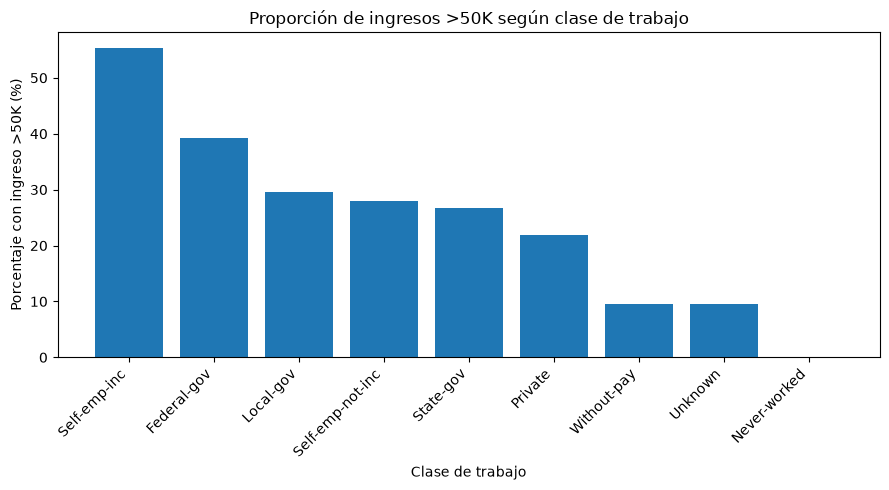

In [31]:
# Graficar relación 

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    workclass_income["workclass"],
    workclass_income["porcentaje_mayor_50K"]
)

plt.title("Proporción de ingresos >50K según clase de trabajo")
plt.xlabel("Clase de trabajo")
plt.ylabel("Porcentaje con ingreso >50K (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

#### Hallazgo y decisión

La **clase de trabajo sí diferencia perfiles de ingreso** y requiere considerar qué representa cada categoría.

- **Self-emp-inc:** trabajadores por cuenta propia con negocio constituido como corporación. Presentan la mayor proporción de `>50K` (**55.4%**).
- **Federal-gov:** empleados del gobierno federal, con **39.2%** de `>50K`.
- **Self-emp-not-inc:** independientes con negocio no incorporado, presentan **27.9%**. Esto muestra que no todos los trabajadores independientes tienen el mismo comportamiento.
- **Private:** empleados del sector privado. Representan la gran mayoría de los registros (**33,860**) y presentan **21.8%** de `>50K`.
- **Unknown:** clase de trabajo no conocida. Presenta solo **9.5%** de `>50K`, un comportamiento diferenciado que respalda conservarla como categoría.

`Without-pay` y `Never-worked` tienen muy pocos registros, por lo que sus porcentajes no se interpretan como patrones robustos.

**Decisión:** conservar `workclass` como predictor. Mantener `Unknown` explícitamente y tratar con cautela las categorías de muy baja frecuencia.

### 4.2 Dimensión laboral — Ocupación (`occupation`)

**Contexto:** `occupation` representa el tipo de actividad laboral desempeñada. A diferencia de `workclass`, no identifica el sector o modalidad de empleo, sino la naturaleza del trabajo realizado.

**Pregunta:** ¿qué ocupaciones presentan diferencias relevantes en la proporción de ingresos `>50K`?

**Propósito:** evaluar si el tipo de ocupación aporta señal predictiva, considerando también el tamaño de cada grupo y evitando interpretar categorías pequeñas como patrones robustos.

In [32]:
# Distribución de actividades laborales con el ingreso >50K

occupation_income = (
    df.groupby("occupation")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
      .sort_values("porcentaje_mayor_50K", ascending=False)
)

occupation_income

,occupation,n,porcentaje_mayor_50K
3,Exec-managerial,6082,47.780335
9,Prof-specialty,6165,45.125710
1,Armed-Forces,15,33.333333
10,Protective-serv,982,31.364562
12,Tech-support,1445,29.065744
11,Sales,5501,26.813307
2,Craft-repair,6102,22.648312
13,Transport-moving,2355,20.424628
0,Adm-clerical,5606,13.699608
6,Machine-op-inspct,3017,12.296984


#### ¿Qué representan estas categorías?

Las categorías de `occupation` agrupan tipos de actividad laboral y no puestos
específicos. Algunas etiquetas requieren contexto para su interpretación:

- **Exec-managerial:** funciones ejecutivas, gerenciales y de dirección.
- **Prof-specialty:** ocupaciones profesionales especializadas.
- **Tech-support:** soporte y actividades técnicas.
- **Protective-serv:** servicios de protección y seguridad.
- **Sales:** ocupaciones relacionadas con ventas.
- **Craft-repair:** oficios especializados, reparación y mantenimiento.
- **Transport-moving:** transporte y movimiento de materiales.
- **Adm-clerical:** funciones administrativas y de oficina.
- **Machine-op-inspct:** operación e inspección de maquinaria.
- **Farming-fishing:** agricultura, pesca y actividades relacionadas.
- **Handlers-cleaners:** manipulación de materiales, limpieza y trabajos afines.
- **Other-service:** otras ocupaciones de servicios.
- **Priv-house-serv:** servicios domésticos en hogares privados.
- **Armed-Forces:** fuerzas armadas.
- **Unknown:** ocupación no informada.

Estas categorías describen **familias ocupacionales amplias**, por lo que sus
resultados deben interpretarse como patrones del dataset y no como características
de cada persona u ocupación individual.

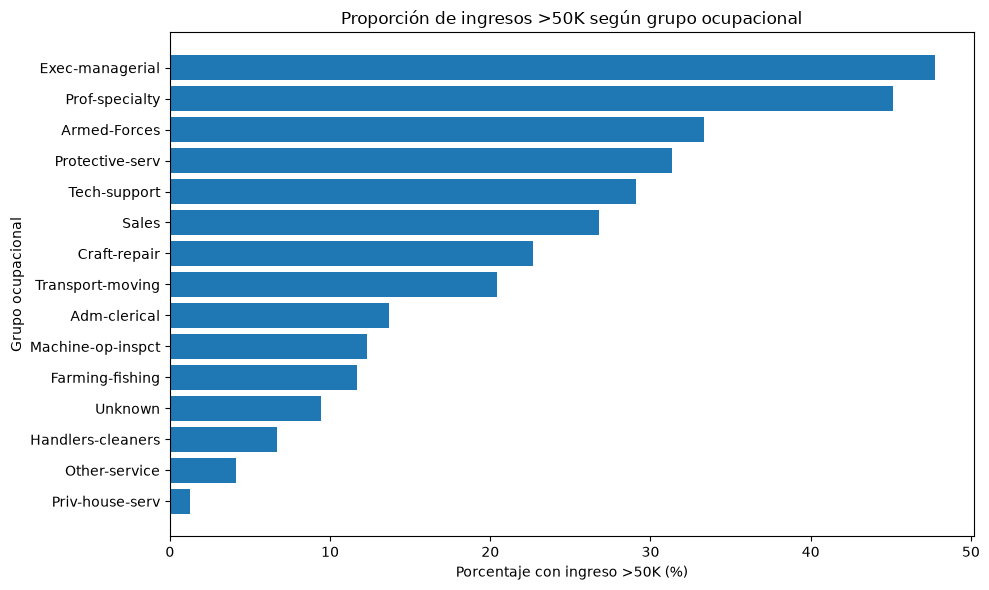

In [33]:
#Gráfico de la relación 

plt.figure(figsize=(10, 6))

plt.barh(
    occupation_income["occupation"],
    occupation_income["porcentaje_mayor_50K"]
)

plt.title("Proporción de ingresos >50K según grupo ocupacional")
plt.xlabel("Porcentaje con ingreso >50K (%)")
plt.ylabel("Grupo ocupacional")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Hallazgo y decisión

La ocupación muestra una **clara relación con el nivel de ingreso**.

Los grupos **ejecutivos y gerenciales (`Exec-managerial`)** y **profesionales especializados (`Prof-specialty`)** presentan las mayores proporciones de `>50K` (47.8% y 45.1%) y cuentan con más de 6,000 registros cada uno, por lo que el patrón tiene una base sólida.

En contraste, actividades de **servicios, limpieza y trabajo doméstico** presentan proporciones considerablemente menores. Esto refleja diferencias existentes entre tipos de ocupación dentro del mercado laboral representado en el dataset.

`Armed-Forces` alcanza 33.3%, pero solo contiene 15 registros, por lo que no se considera evidencia suficiente para generalizar. `Unknown` mantiene un comportamiento diferenciado (9.5%), respaldando nuevamente su conservación como categoría.

**Decisión:** conservar `occupation` como predictor relevante, manteniendo cautela con categorías poco representadas y evitando interpretar estas asociaciones como relaciones causales.

### 4.3 Dimensión familiar — Estado civil y relación en el hogar

**Contexto:** `marital-status` describe el estado civil, mientras `relationship` indica la relación de la persona con el hogar censado. Son conceptos diferentes, pero pueden contener información relacionada.

**Pregunta:** ¿qué patrones presentan respecto a `income` y cuánto de esa señal podría ser compartida entre ambas variables?

**Propósito:** evaluar su utilidad predictiva, posibles redundancias y riesgos de interpretar como causal una asociación vinculada al contexto familiar y social.

In [34]:
# Relación Estado civil con ingresos >50K

marital_income = (
    df.groupby("marital-status")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
      .sort_values("porcentaje_mayor_50K", ascending=False)
)

marital_income

,marital-status,n,porcentaje_mayor_50K
2,Married-civ-spouse,22366,44.612358
1,Married-AF-spouse,37,37.837838
0,Divorced,6630,10.120664
3,Married-spouse-absent,627,9.250399
6,Widowed,1518,8.432148
5,Separated,1530,6.470588
4,Never-married,16082,4.557891


#### ¿Qué representan las principales categorías?

- **Married-civ-spouse:** persona casada con cónyuge civil.
- **Never-married:** nunca se ha casado.
- **Divorced:** divorciada.
- **Separated:** separada legalmente o de hecho.
- **Widowed:** viuda.
- **Married-spouse-absent:** casada, pero el cónyuge está ausente del hogar.
- **Married-AF-spouse:** casada con cónyuge vinculado a las Fuerzas Armadas.

Estas categorías describen el estado civil registrado y no deben interpretarse por sí solas como causa de un determinado nivel de ingreso.

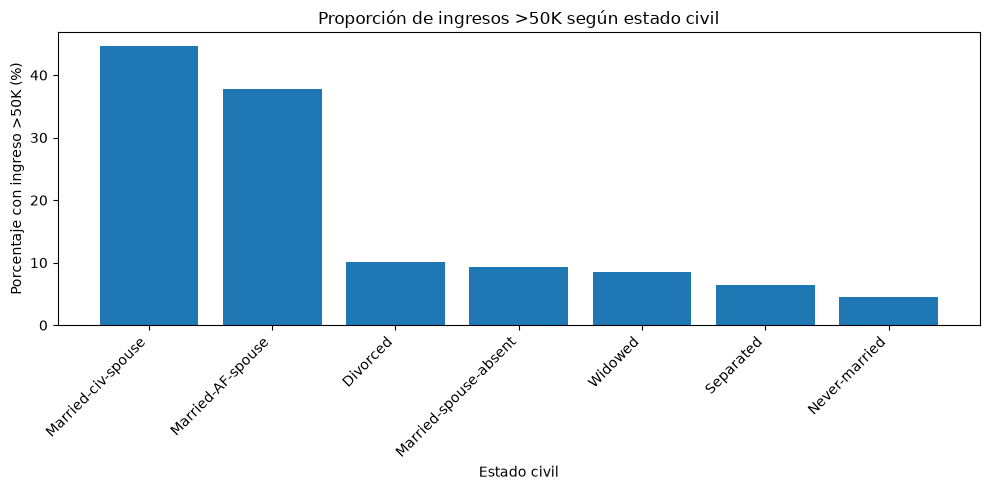

In [35]:
#Graficar la relación 

plt.figure(figsize=(10, 5))

plt.bar(
    marital_income["marital-status"],
    marital_income["porcentaje_mayor_50K"]
)

plt.title("Proporción de ingresos >50K según estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Porcentaje con ingreso >50K (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [36]:
#composición y relación con el ingreso >50K 

relationship_income = (
    df.groupby("relationship")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
      .sort_values("porcentaje_mayor_50K", ascending=False)
)

relationship_income

,relationship,n,porcentaje_mayor_50K
5,Wife,2331,46.889747
0,Husband,19703,44.866264
1,Not-in-family,12557,10.161663
4,Unmarried,5124,6.030445
2,Other-relative,1506,3.452855
3,Own-child,7569,1.466508


#### ¿Qué representa `relationship`?

`relationship` describe la posición o relación de la persona dentro del hogar censado:

- **Husband / Wife:** persona registrada como esposo o esposa dentro del hogar.
- **Own-child:** hijo/a del hogar.
- **Not-in-family:** persona que no forma parte de un núcleo familiar dentro del hogar.
- **Unmarried:** persona no casada dentro de una estructura familiar.
- **Other-relative:** otro familiar distinto de cónyuge o hijo/a.

Estas categorías describen la **estructura del hogar**, no una condición económica por sí mismas.

In [37]:
#evaluar la relación entre marital status y relationship 

cruce_familiar = pd.crosstab(
    df["marital-status"],
    df["relationship"],
    normalize="index"
).mul(100).round(1)

cruce_familiar

relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
marital-status,,,,,,
Divorced,0.0,54.7,2.7,6.9,35.7,0.0
Married-AF-spouse,32.4,0.0,2.7,2.7,0.0,62.2
Married-civ-spouse,88.0,0.1,0.9,0.6,0.0,10.3
Married-spouse-absent,0.0,52.5,8.6,9.7,29.2,0.0
Never-married,0.0,44.1,5.7,41.9,8.3,0.0
Separated,0.0,41.6,5.2,9.5,43.7,0.0
Widowed,0.0,56.1,4.6,1.6,37.7,0.0


#### Hallazgo y decisión

`marital-status` y `relationship` muestran una fuerte relación entre sí y también con `income`.

Por ejemplo, el **98.3% de las personas `Married-civ-spouse`** aparece en el hogar como `Husband` (88.0%) o `Wife` (10.3%). En cambio, `Never-married` se concentra principalmente en `Not-in-family` (44.1%) y `Own-child` (41.9%).

Esto indica que ambas variables describen desde perspectivas diferentes una parte de la **estructura familiar y etapa de vida de la persona**, por lo que parte de su señal predictiva puede ser compartida.

Las diferencias observadas en `income` no deben interpretarse como que estar casado, ser esposo/a o hijo/a cause un determinado nivel de ingreso; pueden reflejar conjuntamente edad, etapa de vida, participación laboral y otras condiciones sociales.

### 4.4 Dimensión sociodemográfica y riesgo de sesgo

Las variables `sex`, `race` y `native-country` describen características
sociodemográficas que pueden reflejar desigualdades presentes en los datos históricos.

**Pregunta:** ¿qué diferencias aparecen respecto a `income` y qué riesgos tendría
incorporar estas variables al modelo?

**Criterio de análisis:**
- Una asociación estadística no implica causalidad.
- Las diferencias observadas describen patrones del dataset, no capacidades inherentes de los grupos.
- Se considerará siempre el tamaño (`n`) y representación de cada categoría.
- La capacidad predictiva no será el único criterio para decidir si una variable debe utilizarse.

**Propósito:** identificar señal, posibles sesgos y variables que requieran evaluación
especial antes del modelado.

In [38]:
#Analisis de relación de la variable género

sex_income = (
    df.groupby("sex")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
)

sex_income

,sex,n,porcentaje_mayor_50K
0,Female,16176,10.935955
1,Male,32614,30.391856


#### Hallazgo inicial

El dataset presenta una diferencia importante según `sex`: el **30.4% de los hombres**
y el **10.9% de las mujeres** registra ingresos `>50K`.

La diferencia es estadísticamente visible y está respaldada por grupos numerosos.
Sin embargo, **no implica que el sexo sea la causa de la diferencia de ingresos**.

Antes de decidir su uso en el modelo, se evaluará cuánto de esta asociación puede
estar relacionada con otras características laborales y educativas presentes en los datos.

In [39]:
#integración de la variable educación con género e ingreso >50K 

sex_education = (
    df.groupby(["education", "sex"])["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
)

sex_education

,education,sex,n,porcentaje_mayor_50K
0,10th,Female,457,0.875274
1,10th,Male,932,8.905579
2,11th,Female,650,1.692308
3,11th,Male,1162,6.970740
4,12th,Female,210,1.904762
5,12th,Male,445,9.887640
6,1st-4th,Female,59,0.000000
7,1st-4th,Male,186,4.301075
8,5th-6th,Female,127,3.149606
9,5th-6th,Male,380,6.052632


In [40]:
# relación variable ocupación con genero e ingreso: 

sex_occupation = (
    df.groupby(["occupation", "sex"])["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
)

sex_occupation

,occupation,sex,n,porcentaje_mayor_50K
0,Adm-clerical,Female,3764,8.209352
1,Adm-clerical,Male,1842,24.918567
2,Armed-Forces,Male,15,33.333333
3,Craft-repair,Female,323,10.216718
4,Craft-repair,Male,5779,23.343139
5,Exec-managerial,Female,1748,24.084668
6,Exec-managerial,Male,4334,57.337333
7,Farming-fishing,Female,95,3.157895
8,Farming-fishing,Male,1390,12.230216
9,Handlers-cleaners,Female,254,3.149606


#### Hallazgo — Señal sensible y contexto histórico

En los datos de 1994 existe una diferencia importante en la proporción de ingresos
`>50K`: **30.4% en hombres frente a 10.9% en mujeres**.

La diferencia **persiste al comparar los mismos niveles educativos y también dentro
de múltiples grupos ocupacionales**. Por ejemplo, en `Exec-managerial` supera
US$50K el 57.3% de los hombres frente al 24.1% de las mujeres; en
`Prof-specialty`, 56.1% frente a 26.0%.

Por tanto, la asociación observada no parece explicarse únicamente por educación
u ocupación. Puede reflejar otras diferencias laborales, familiares y sociales
presentes en el mercado estadounidense de la época que este dataset no permite
aislar completamente.

**Precaución:** estos resultados describen asociaciones históricas del dataset;
no demuestran causalidad ni diferencias de capacidad entre hombres y mujeres.

**Decisión:** tratar `sex` como variable sensible. Su capacidad predictiva no será
suficiente para justificar su uso: deberá evaluarse también su impacto en equidad
y desempeño por grupos antes de decidir su incorporación al modelo.

#### 4.4.2 Raza (`race`)

`race` corresponde a la clasificación racial registrada en el dataset.

Por tratarse de una variable sensible, su análisis busca identificar patrones
históricos y posibles riesgos de sesgo, no atribuir diferencias de ingreso a
características inherentes de los grupos.

**Pregunta:** ¿existen diferencias en `income` entre las categorías registradas
y qué tan representados están esos grupos?

In [41]:
# Distribución y relación de race con income

race_income = (
    df.groupby("race")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
      .sort_values("n", ascending=False)
)

race_income

,race,n,porcentaje_mayor_50K
4,White,41714,25.413530
2,Black,4683,12.086269
1,Asian-Pac-Islander,1517,26.961107
0,Amer-Indian-Eskimo,470,11.702128
3,Other,406,12.315271


#### Hallazgo — Diferencias con representación desigual

La variable `race` presenta diferencias en la proporción de ingresos `>50K`,
pero también un fuerte desbalance de representación.

`White` concentra aproximadamente **85.5% de los registros**, mientras las demás
categorías tienen una presencia considerablemente menor. Las proporciones de
`>50K` varían entre los grupos, pero estas diferencias deben interpretarse como
**asociaciones históricas presentes en el dataset**, no como características
inherentes de las personas.

La baja representación de algunos grupos también implica que un buen desempeño
global del modelo podría ocultar resultados diferentes entre grupos minoritarios.

**Decisión:** tratar `race` como variable sensible. Evaluar su aporte predictivo,
su representación y el desempeño del modelo por grupos antes de decidir su uso
como predictor.

#### 4.4.3 País de origen (`native-country`)

`native-country` registra el país de origen declarado en el censo.

Esta variable requiere especial cuidado porque combina **alta cantidad de categorías,
representación desigual y posible información asociada al contexto migratorio y social**.

**Pregunta:** ¿qué tan representados están los distintos países y existe evidencia
suficiente para considerar esta variable útil en el modelado?

**Propósito:** identificar problemas de baja frecuencia, posibles agrupaciones para
Feature Engineering y riesgos de sesgo antes de utilizarla como predictor.

In [42]:
# Cantidad, proporción y relación de la variable país de origen con ingreso >50K 

country_income = (
    df.groupby("native-country")["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
)

country_income["porcentaje_muestra"] = (
    country_income["n"] / len(df) * 100
).round(2)

country_income = (
    country_income
      .sort_values("n", ascending=False)
)

country_income

,native-country,n,porcentaje_mayor_50K,porcentaje_muestra
38,United-States,43792,24.406284,89.76
25,Mexico,943,4.984093,1.93
39,Unknown,856,25.700935,1.75
29,Philippines,294,28.911565,0.60
10,Germany,206,28.155340,0.42
32,Puerto-Rico,184,10.869565,0.38
1,Canada,182,34.615385,0.37
7,El-Salvador,155,7.096774,0.32
18,India,151,41.059603,0.31
4,Cuba,138,24.637681,0.28


In [43]:
resumen_country = pd.Series({
    "Número de países/categorías": len(country_income),
    "Categorías con menos de 100 registros": (country_income["n"] < 100).sum(),
    "Categorías con menos de 50 registros": (country_income["n"] < 50).sum(),
    "Categorías con menos de 20 registros": (country_income["n"] < 20).sum(),
    "Porcentaje concentrado en la categoría mayoritaria":
        country_income.iloc[0]["porcentaje_muestra"]
})

resumen_country

Número de países/categorías                           42.00
Categorías con menos de 100 registros                 26.00
Categorías con menos de 50 registros                  17.00
Categorías con menos de 20 registros                   2.00
Porcentaje concentrado en la categoría mayoritaria    89.76
dtype: float64

#### Hallazgo — Alta fragmentación y representación desigual

`native-country` contiene **42 categorías**, pero su representación es altamente
desigual: una sola categoría concentra **89.8% de los registros**.

Además, **26 categorías tienen menos de 100 observaciones** y 17 tienen menos de 50.
Por ello, porcentajes aparentemente altos o bajos de ingresos `>50K` en algunos
países pueden estar sustentados por muestras demasiado pequeñas para considerarlos
patrones robustos.

`native-country` representa país de origen y no debe interpretarse directamente
como nacionalidad, condición migratoria o capacidad económica de una población.

**Decisión:** no utilizar las 42 categorías de forma directa sin evaluar su
estabilidad. Considerar agrupación de categorías poco frecuentes durante Feature
Engineering y tratar `native-country` como variable sensible, evaluando además
su aporte predictivo y posibles efectos de sesgo.

## 5. Relaciones entre variables

Hasta ahora analizamos las variables individualmente y su relación con `income`.
En esta sección buscamos identificar **redundancias e interacciones relevantes**
que puedan afectar la construcción del modelo.

**Pregunta guía:** *¿qué relaciones entre variables cambian una decisión de
Feature Engineering o modelado?*

### 5.1 Redundancia: `education` y `education-num`

El análisis de educación (Sección 3.2) confirmó una **correspondencia uno-a-uno**
entre `education` y `education-num`: ambas representan el mismo nivel educativo
en formatos diferentes.

**Decisión:** no tratarlas como información independiente. En Feature Engineering
se definirá qué representación conservar según el modelo utilizado.

### 5.2 Relación entre `marital-status` y `relationship`

El análisis de la dimensión familiar (Sección 4.3) mostró que ambas variables
describen aspectos diferentes pero **fuertemente relacionados de la estructura
del hogar y etapa de vida**.

Por ejemplo, el 98.3% de `Married-civ-spouse` se concentra en las categorías
`Husband` y `Wife`, evidenciando información parcialmente compartida.

**Decisión:** conservar inicialmente ambas variables, pero evaluar en Feature
Engineering/modelado si utilizarlas conjuntamente aporta información adicional
o introduce redundancia innecesaria.

### 5.3 Educación y ocupación

Educación y ocupación mostraron individualmente una fuerte relación con `income`.

**Pregunta:** *¿la ocupación aporta información adicional dentro de niveles
educativos similares o ambas variables reflejan principalmente la misma señal?*

In [44]:
# Relación entre las variables Educación y ocupación con Income

niveles_educacion = [
    "HS-grad",
    "Some-college",
    "Bachelors",
    "Masters"
]

edu_ocupacion = (
    df[df["education"].isin(niveles_educacion)]
      .groupby(["education", "occupation"])["income"]
      .agg(
          n="size",
          porcentaje_mayor_50K=lambda x: (x == ">50K").mean() * 100
      )
      .reset_index()
)

edu_ocupacion = edu_ocupacion[
    edu_ocupacion["n"] >= 100
].sort_values(
    ["education", "porcentaje_mayor_50K"],
    ascending=[True, False]
)

edu_ocupacion

,education,occupation,n,porcentaje_mayor_50K
3,Bachelors,Exec-managerial,2022,55.291790
10,Bachelors,Protective-serv,147,51.700680
11,Bachelors,Sales,1267,47.119179
9,Bachelors,Prof-specialty,2230,39.865471
2,Bachelors,Craft-repair,330,39.696970
12,Bachelors,Tech-support,346,34.393064
4,Bachelors,Farming-fishing,113,27.433628
0,Bachelors,Adm-clerical,763,25.294889
14,Bachelors,Unknown,252,23.809524
7,Bachelors,Other-service,259,13.899614


### 5.3 Educación y ocupación

El nivel educativo y el tipo de ocupación aportan **información diferente y
complementaria** sobre `income`.

Incluso entre personas con el mismo nivel educativo aparecen diferencias importantes.
Por ejemplo, entre quienes tienen `Bachelors` (grado universitario):

- **Exec-managerial** (puestos ejecutivos o gerenciales): **55.3%** supera US$50K.
- **Adm-clerical** (puestos administrativos y de oficina): **25.3%**.
- **Other-service** (otras actividades de servicios): **13.9%**.

También ocurre en sentido contrario. Dentro de `Exec-managerial`, la proporción
de `>50K` aumenta según el nivel educativo:

**HS-grad 32.6% → Some-college 36.4% → Bachelors 55.3% → Masters 73.3%.**

**Hallazgo:** educación y ocupación están relacionadas, pero una no sustituye a la
otra; ambas ayudan a diferenciar perfiles de ingreso.

**Decisión:** conservar inicialmente ambas variables y evaluar su aporte conjunto
durante el modelado.

### 5.4 Síntesis de relaciones relevantes

El análisis conjunto permitió distinguir tres situaciones importantes:

- **Información redundante:** `education` y `education-num` representan el mismo nivel educativo mediante formatos diferentes.
- **Información parcialmente compartida:** `marital-status` y `relationship` describen dimensiones relacionadas de la estructura familiar y etapa de vida.
- **Información complementaria:** `education` y `occupation` están relacionadas, pero ambas conservan capacidad para diferenciar perfiles de ingreso.

**Decisión:** trasladar estas relaciones a Feature Engineering y modelado para evitar redundancias innecesarias sin eliminar variables que aportan información complementaria.

## 6. Robustez y generalización

**Pregunta:** *¿Qué características del dataset podrían producir señales inestables
o un desempeño del modelo que no generalice adecuadamente?*

**Propósito:** identificar riesgos que deberán considerarse durante Feature
Engineering, partición de datos, entrenamiento y evaluación.

### 6.1 Representación desigual

El EDA identificó grupos con tamaños muy diferentes:

- Algunas edades avanzadas presentan muy pocas observaciones.
- `Armed-Forces` y otras categorías laborales tienen baja representación.
- `race` está fuertemente concentrada en la categoría mayoritaria.
- `native-country` contiene 42 categorías, muchas con menos de 100 registros.

**Riesgo:** porcentajes extremos en grupos pequeños pueden ser inestables y el
desempeño global del modelo puede ocultar un comportamiento deficiente en grupos
minoritarios.

**Decisión:** utilizar particiones estratificadas por `income`, validación cruzada
y evaluar desempeño por grupos relevantes. Las categorías de muy baja frecuencia
se revisarán durante Feature Engineering.

### 6.2 Desbalance de la variable objetivo

La variable objetivo `income` presenta un desbalance aproximado de **76% `<=50K`
frente a 24% `>50K`**.

Aunque ambas clases tienen suficiente representación, un modelo podría obtener una
exactitud aparentemente alta favoreciendo la clase mayoritaria sin identificar
adecuadamente a las personas `>50K`.

**Implicación:** la selección del modelo no debe basarse únicamente en `accuracy`.

**Decisión:** utilizar partición estratificada y comparar los modelos mediante
métricas que permitan evaluar ambas clases, especialmente `precision`, `recall`,
`F1-score` y matriz de confusión. Durante el modelado se evaluará si el uso de
pesos de clase mejora el desempeño sin introducir un deterioro injustificado
en la clase mayoritaria.

#### Consideración histórica y riesgo de sesgo

El dataset representa condiciones laborales, económicas y sociales de Estados Unidos
en **1994**, por lo que el modelo puede aprender patrones propios de ese contexto
histórico, incluidas desigualdades presentes en los datos.

Las asociaciones encontradas en variables como `sex`, `race`, `native-country`,
estado civil u ocupación **no deben interpretarse como características inherentes
de las personas ni trasladarse automáticamente al contexto actual**.

**Decisión:** además del desempeño predictivo global, el modelo deberá evaluarse
por grupos relevantes y documentar posibles diferencias de desempeño. Las variables
sensibles podrán conservarse para auditoría aun cuando se decida no utilizarlas
como predictores.

### 6.3 Riesgos de sobreajuste y generalización

El EDA identificó características que podrían favorecer un buen desempeño aparente
en entrenamiento sin garantizar que el modelo generalice adecuadamente:

- **Categorías poco frecuentes:** algunas ocupaciones, países de origen y grupos
  demográficos tienen pocas observaciones.
- **Alta fragmentación:** `native-country` contiene 42 categorías, muchas con baja
  representación.
- **Información redundante:** `education` y `education-num` representan esencialmente
  la misma característica; `marital-status` y `relationship` comparten parte de su señal.
- **Variables sensibles:** `sex`, `race` y `native-country` pueden aportar capacidad
  predictiva, pero también reflejar patrones sociales e históricos del dataset.
- **Desbalance del objetivo:** la clase `>50K` representa aproximadamente una cuarta
  parte de los registros.

**Riesgo:** un modelo demasiado complejo podría aprender categorías minoritarias,
redundancias o patrones históricos específicos del conjunto de entrenamiento en
lugar de relaciones que generalicen adecuadamente.

**Decisión:** comparar modelos mediante validación cruzada y métricas adecuadas al
desbalance, controlar su complejidad y evaluar diferencias entre entrenamiento y
validación. El mejor modelo será el que generalice de forma consistente, no
necesariamente el que obtenga el mayor desempeño en entrenamiento.

## 7. Síntesis ejecutiva del EDA y continuidad del pipeline

El EDA permitió transformar la exploración de los datos en decisiones concretas
para las siguientes etapas del proyecto.

Esta síntesis reúne únicamente los hallazgos que modifican una decisión de
Feature Engineering, modelado o evaluación, y funciona como punto de partida
para continuar el pipeline sin necesidad de reinterpretar todo el análisis.

| Hallazgo | Evidencia principal | Implicación | Decisión siguiente |
|---|---|---|---|
| Objetivo desbalanceado | ~76% `<=50K` y ~24% `>50K` | `accuracy` puede ser engañosa | Estratificar y evaluar precision, recall, F1 y matriz de confusión; probar pesos de clase |
| Educación relevante | La proporción `>50K` aumenta claramente con niveles educativos superiores | Fuerte señal predictiva | Conservar educación |
| `education` / `education-num` | Correspondencia uno-a-uno | Información redundante | Evaluar conservar una sola representación |
| Ocupación relevante | Ejecutivos/profesionales muestran patrones distintos de servicios y otras ocupaciones | Aporta señal adicional a educación | Conservar `occupation` |
| Educación + ocupación | Dentro del mismo nivel educativo persisten diferencias por ocupación | Son señales complementarias | Evaluar ambas conjuntamente |
| Capital | `capital-gain/loss` tienen muchos ceros, pero fuerte señal cuando están presentes | Variables escasas pero potencialmente informativas | Conservar y evaluar indicadores de presencia |
| `fnlwgt` | Escasa separación descriptiva entre clases | Su valor principal es muestral/metodológico | Evaluar su aporte antes de usarlo como predictor |
| Estructura familiar | `marital-status` y `relationship` comparten parte importante de la información | Posible redundancia | Evaluar aporte incremental de ambas |
| Categorías poco frecuentes | Varias ocupaciones y países tienen `n` reducido | Riesgo de patrones inestables | Revisar agrupación de categorías en Feature Engineering |
| `native-country` | 42 categorías; 89.8% concentrado en una sola y muchas categorías pequeñas | Alta fragmentación | No codificar ingenuamente las 42 categorías; evaluar agrupación |
| Variables sensibles | `sex`, `race` y `native-country` muestran asociaciones con `income` y representación desigual | Riesgo de reproducir patrones históricos y sesgos | Evaluar equidad y decidir separadamente uso predictivo y uso para auditoría |

### Próximos pasos

A partir de estos hallazgos, Feature Engineering y modelado deberán:

1. Resolver redundancias y categorías de baja frecuencia.
2. Definir la codificación adecuada de variables categóricas.
3. Evaluar transformaciones propuestas para `capital-gain` y `capital-loss`.
4. Definir el tratamiento predictivo de `fnlwgt`.
5. Separar las variables sensibles utilizadas para predicción de aquellas conservadas para auditoría.
6. Realizar particiones estratificadas y validación cruzada.
7. Comparar modelos con métricas adecuadas al desbalance, no únicamente `accuracy`.
8. Evaluar generalización, sobreajuste y desempeño por grupos relevantes.